# Beta Inverse CDF

Computing the inverse of the incomplete beta function.

In [1]:
%reload_ext autoreload
%autoreload 2

In [7]:
from probjax.utils.special.gammaincinv import gammaincinv
from probjax.utils.special.betaincinv import betaincinv, _initial_guess_large_ab, _compute_initial_guess
from scipy.special import betaincinv as scipy_betaincinv
from scipy.special import betaincinv as scipy_betaincinv

import jax
from jax.scipy.special import betainc, gammainc
import jax.numpy as jnp
import numpy as np

import matplotlib.pyplot as plt

# jax.config.update("jax_enable_x64", False)
# jax.config.update("jax_platform_name", "cpu")

In [8]:
def bracket_x(a,b, p):

    # Compute the beta function value
    beta_ab = jax.scipy.special.beta(a, b)

    # Lower bound for x
    lower_bound = (p * a * beta_ab) ** (1 / a)
    lower_bound = jnp.where(b >= 1., lower_bound, 0)

    # Upper bound for x
    upper_bound1 = 1 - ((1 - p) * b * beta_ab) ** (1 / b)
    upper_bound2 =  1.
    upper_bound = jnp.where(a < 1, upper_bound2, upper_bound1)
    # Ensure bounds are within [0, 1]
    lower_bound = jnp.clip(lower_bound, 0, 1)
    upper_bound = jnp.clip(upper_bound, 0, 1)

    return lower_bound, upper_bound

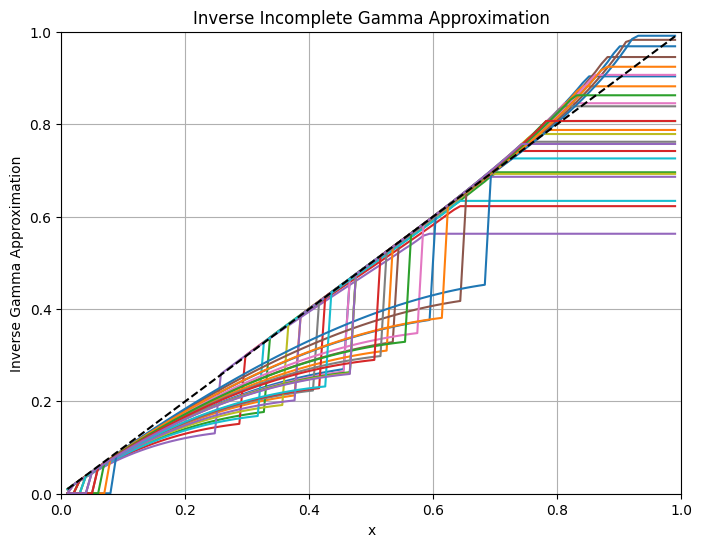

In [9]:
# Example usage


plt.figure(figsize=(8, 6))
for a in jnp.linspace(20, 50, 5):
    for b in jnp.linspace(20, 50, 5):
        x = jnp.linspace(0.01, 0.99, 100)
        p = betainc(a,b ,x)
        l = _compute_initial_guess(a, b, p)
        plt.plot(x, l, label=f"a = {a}, b={b}",)
        #plt.plot(x, x_approx2, label=f"a = {a}", linestyle="--")

plt.plot(x, x, label="y = x", linestyle="--", color="black")
plt.xlabel("x")
plt.xlim(0,1)
plt.ylim(0,1)
plt.ylabel("Inverse Gamma Approximation")
plt.title("Inverse Incomplete Gamma Approximation")
#plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from probjax.utils.stats import betaincinv, _compute_initial_guess, _initial_guess_small_ab, _initial_guess_large_ab, asymptotic_guess_p_to_0, asymptotic_guess_p_to_1

In [ ]:
# Example usage

a_values = jnp.linspace(0.001, 50, 100)
b_values = jnp.linspace(0.001, 50, 100)
x = jnp.linspace(0.01, 0.99, 100)
error_map = np.zeros((len(a_values), len(b_values)))

for i, a in enumerate(a_values):
    for j, b in enumerate(b_values):
        p = betainc(a, b, x)
        x_approx = betaincinv(a, b, p)
        x_approx2 = scipy_betaincinv(a, b, p)
        error = jnp.abs(x_approx - x_approx2)
        error_map[i, j] = jnp.mean(error)

plt.figure(figsize=(10, 8))
plt.imshow(error_map, extent=[0.01, 50, 0.01, 50], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute Error')
plt.xlabel('a')
plt.ylabel('b')
plt.title('2D Error Map of Inverse Incomplete Beta Function Approximations')
plt.grid(True)
plt.show()

KeyboardInterrupt: 

In [ ]:
%%timeit
x_approx = betaincinv(a,b, p).block_until_ready()

289 ms ± 10.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
x_approx = betainc(a,b, p).block_until_ready()

16 ms ± 399 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
a = 0.1
b = 5.
p = betainc(a,b ,x)

betaincinv(a,b, p[-10:-5])

Array([0.90203327, 0.91454077, 0.925472  , 0.925472  , 1.        ],      dtype=float32)

In [ ]:
from probjax.utils.stats import betaincinv, _compute_initial_guess, _initial_guess_small_ab, _initial_guess_large_ab, asymptotic_guess_p_to_0, asymptotic_guess_p_to_1

In [ ]:
from jax.scipy.special import betainc, gammaln
log_Bab = gammaln(a) + gammaln(b) - gammaln(a + b)
    # leading term: 1 - x ~ [b * B(a,b) * (1-p)]^(1/b)
log_1mx = (1.0 / b) * (jnp.log(b) + log_Bab + jnp.log1p(-p))

In [ ]:
 jnp.log1p(-p)

Array([ -1.4656962,  -1.7201413,  -1.9092313,  -2.0680945,  -2.209116 ,
        -2.3382602,  -2.4589093,  -2.5732093,  -2.6826131,  -2.7881105,
        -2.890486 ,  -2.9902954,  -3.0880005,  -3.1839056,  -3.2785017,
        -3.372008 ,  -3.464417 ,  -3.556041 ,  -3.6470363,  -3.7375407,
        -3.827677 ,  -3.9175587,  -4.007285 ,  -4.0969453,  -4.1866274,
        -4.276408 ,  -4.366363 ,  -4.4565587,  -4.5470614,  -4.637936 ,
        -4.729248 ,  -4.8210516,  -4.9134083,  -5.0063715,  -5.0999947,
        -5.19435  ,  -5.2894764,  -5.3854403,  -5.4823008,  -5.580097 ,
        -5.6789007,  -5.7787857,  -5.879781 ,  -5.9819503,  -6.085413 ,
        -6.1901565,  -6.296309 ,  -6.4039288,  -6.51307  ,  -6.6238184,
        -6.736304 ,  -6.850547 ,  -6.9666286,  -7.084728 ,  -7.204852 ,
        -7.327158 ,  -7.451741 ,  -7.578693 ,  -7.708218 ,  -7.8404045,
        -7.9754515,  -8.113352 ,  -8.254388 ,  -8.398847 ,  -8.546663 ,
        -8.698515 ,  -8.853976 ,  -9.013847 ,  -9.177923 ,  -9.3

In [ ]:
1/b

0.2

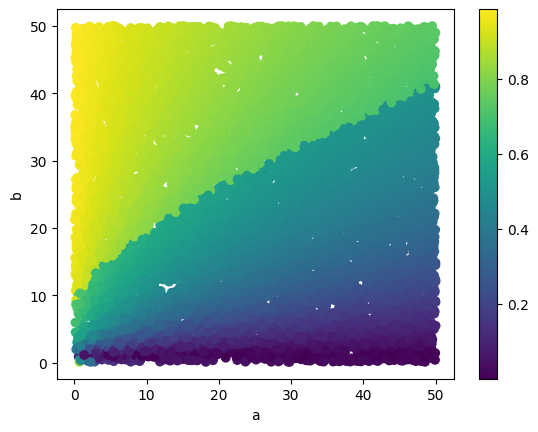

In [ ]:
a = np.random.uniform(.1, 50, 10000)
b = np.random.uniform(.1, 50, 10000)



x= 0.8
p = betainc(a,b, x)
x_approx = asymptotic_guess_p_to_0(a,b, p)
x = scipy_betaincinv(a,b, p)
error = jnp.abs(x - x_approx)



plt.scatter(a, b, c=error, cmap="viridis")
plt.xlabel("a")
plt.ylabel("b")
plt.colorbar()


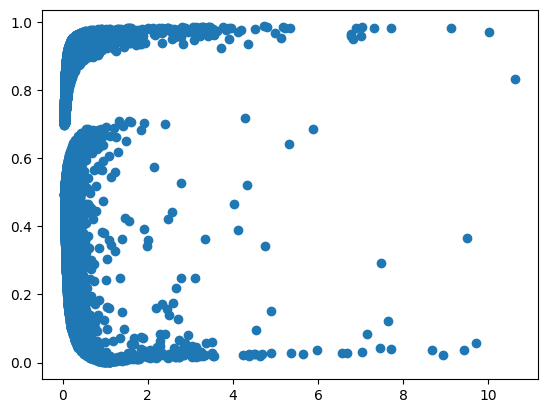

In [ ]:
plt.plot(1/b + 1/a, error, "o")

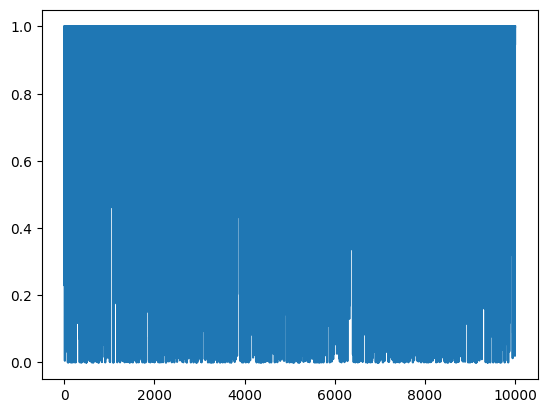

In [ ]:
plt.plot(p)